/home/mmc-moweather/anaconda3/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font famil

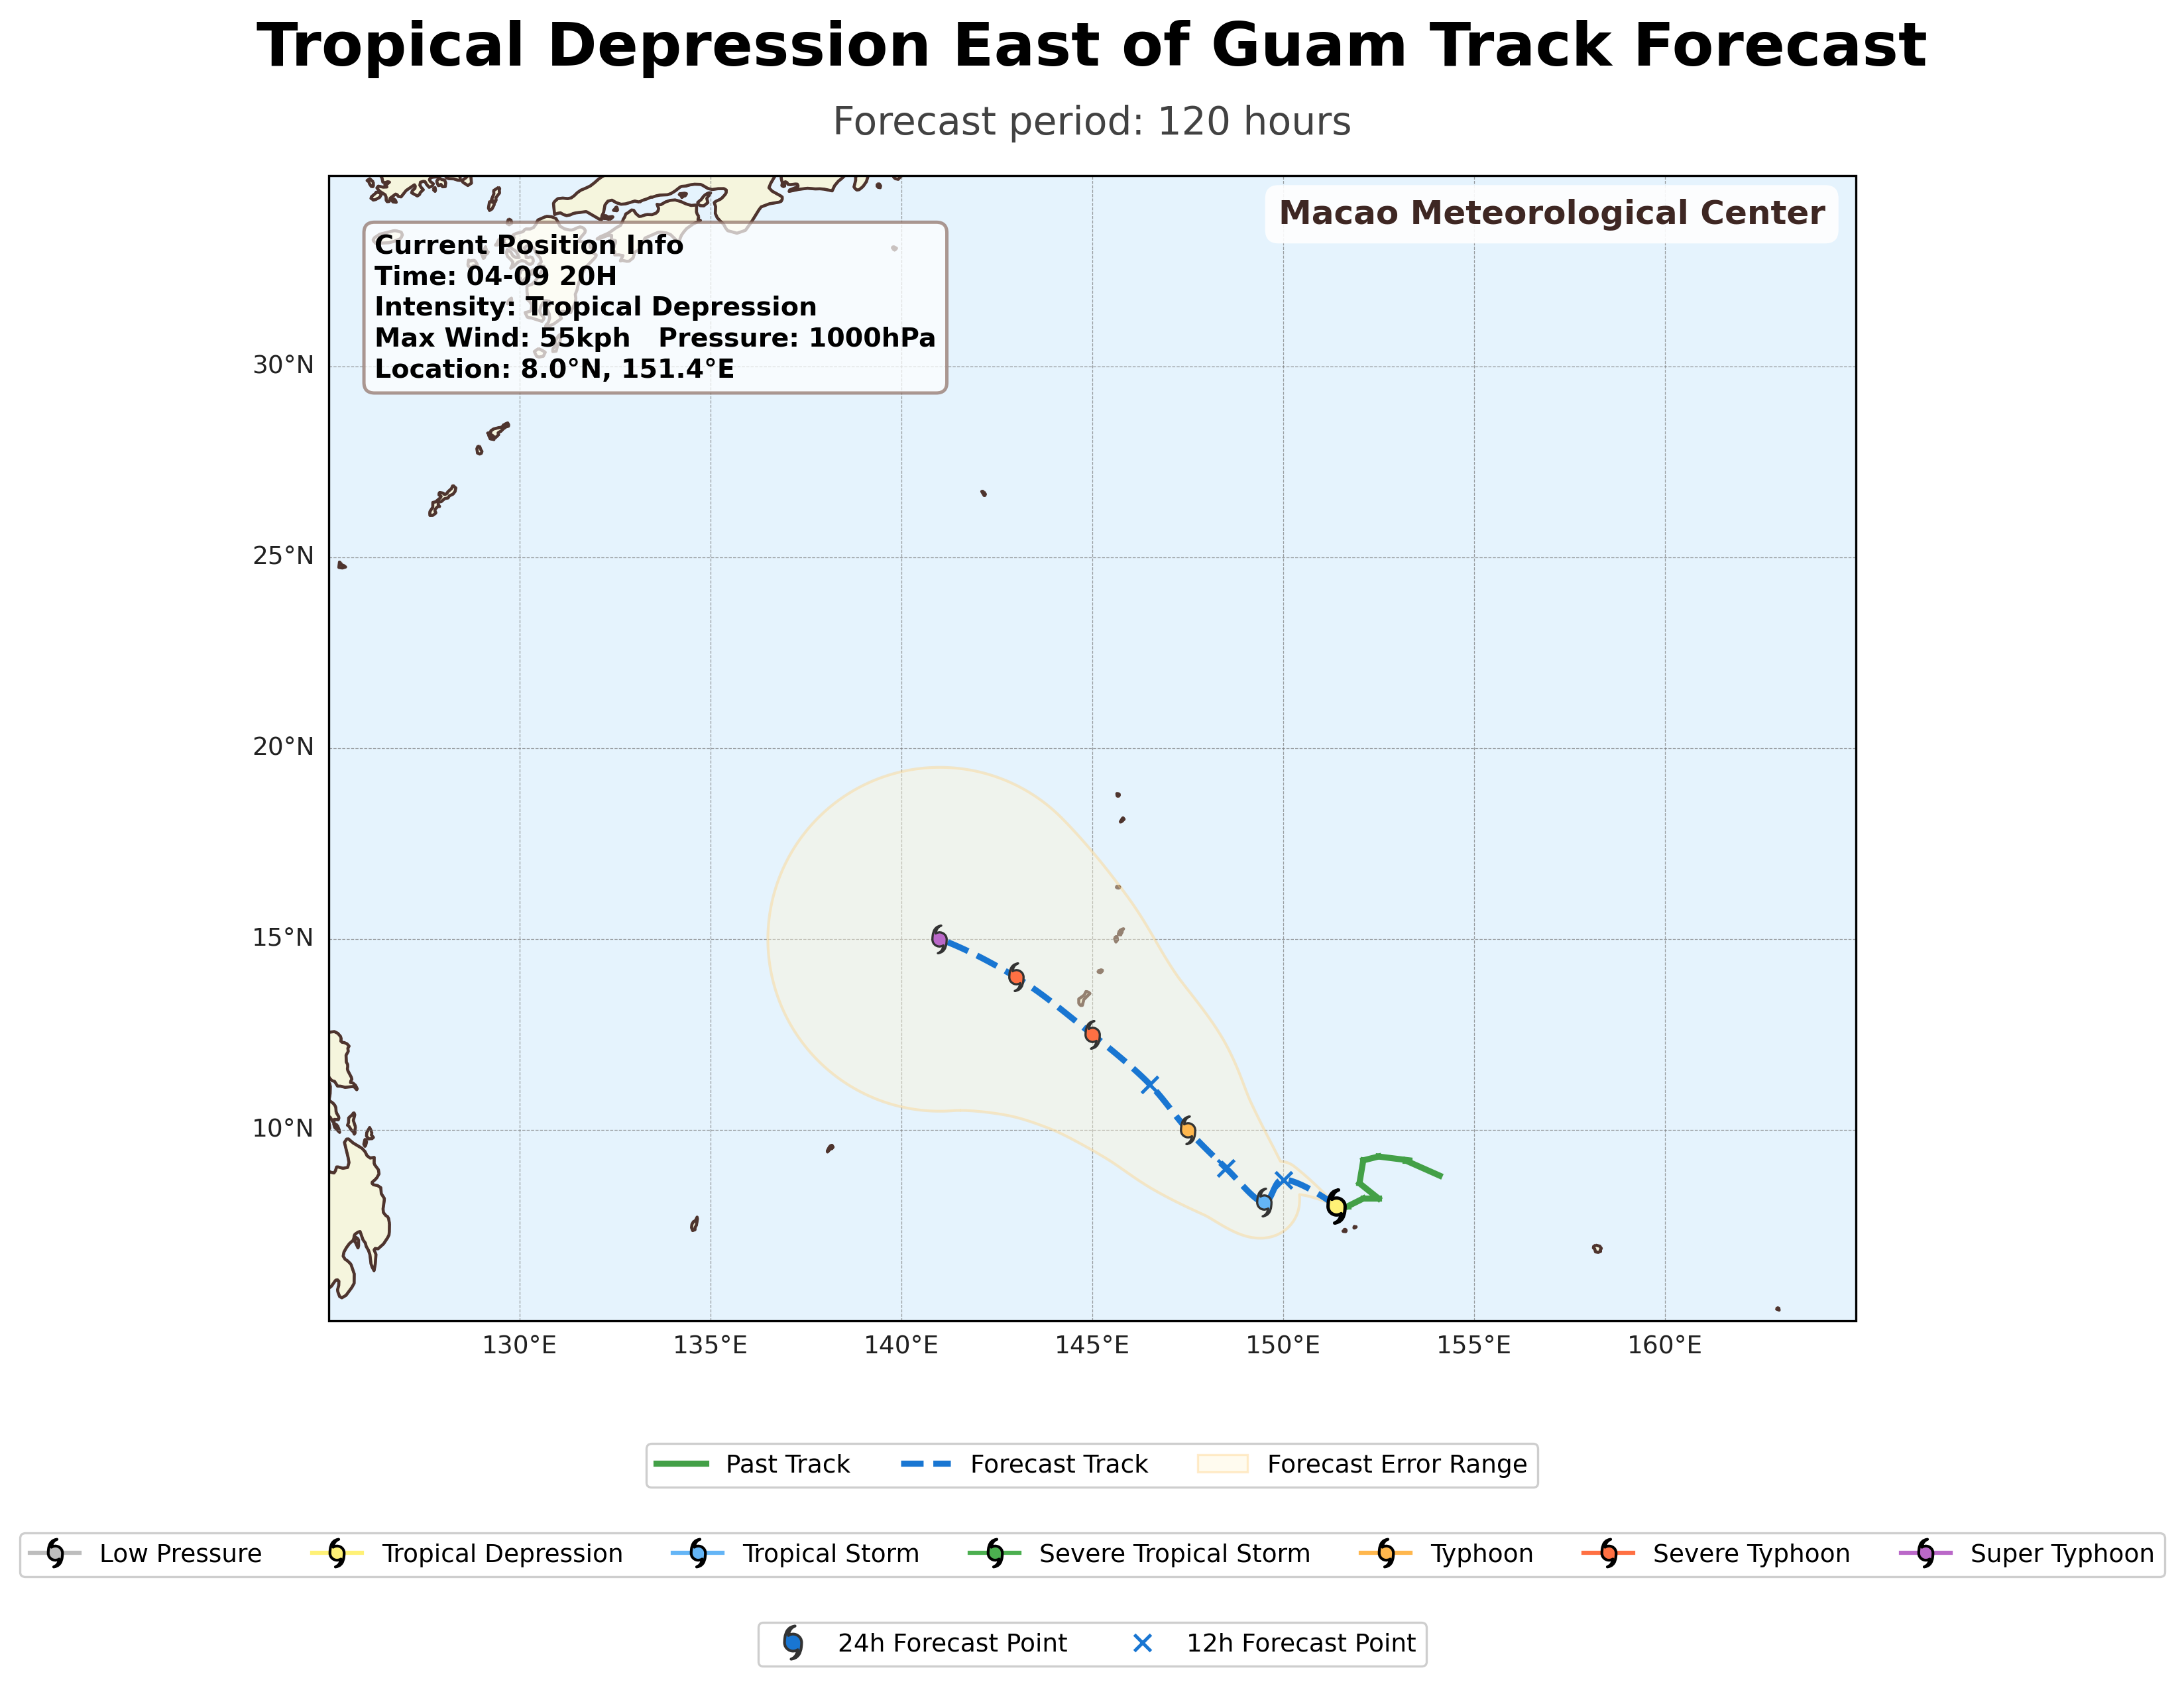

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
from scipy.interpolate import PchipInterpolator
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
import matplotlib.colors as mcolors
import tcmarkers

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 10
plt.rcParams["legend.framealpha"] = 0.95
plt.rcParams["axes.titlepad"] = 25
plt.rcParams["patch.linewidth"] = 0.8

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['agg.path.chunksize'] = 0
plt.rcParams['lines.antialiased'] = True
plt.rcParams['text.antialiased'] = True
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.0

extent = [125.0, 165.0, 5.0, 35.0]
MACAO_LON, MACAO_LAT = 113.55, 22.17
MACAO_SAFE_RADIUS = 2.0
LAT_TO_KM = 110.574

def lon_to_km_factor(latitude):
    return 111.320 * np.cos(np.radians(latitude))

MACAO_ALERT_CIRCLES = [
    (100, "#A0A0A0", 0.2, 0.8),
    (200, "#808080", 0.3, 0.9),
    (400, "#808080", 0.4, 1.0),
    (600, "#A0A0A0", 0.5, 1.1),
    (800, "#FF4D4D", 0.6, 1.8),
]

ERROR_CIRCLE_FILL = "#FFF5D7"
ERROR_CIRCLE_EDGE = "#FFD180"
ERROR_CIRCLE_ALPHA = 0.4
PAST_PATH_COLOR = "#43A047"
FORECAST_PATH_COLOR = "#1976D2"
PATH_WIDTH = 2.2
KM_TO_DEG = 1 / 111

LABEL_BBOX = dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.7, edgecolor="gray", linewidth=0.4)
FORECAST_LABEL_BBOX = dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.7, edgecolor="gray", linewidth=0.4)
MARKER_SIZE = 5
X_MARKER_SIZE = 6

def get_intensity_info(wind_speed, cyclone_type="tropical"):
    if wind_speed < 41:
        return ("Low Pressure", "#BDBDBD", tcmarkers.HU)
    elif 41 <= wind_speed <= 62:
        return ("Tropical Depression", "#FFF176", tcmarkers.HU)
    elif 63 <= wind_speed <= 87:
        return ("Tropical Storm", "#64B5F6", tcmarkers.HU)
    elif 88 <= wind_speed <= 117:
        return ("Severe Tropical Storm", "#4CAF50", tcmarkers.HU)
    elif 118 <= wind_speed <= 149:
        return ("Typhoon", "#FFB74D", tcmarkers.HU)
    elif 150 <= wind_speed <= 184:
        return ("Severe Typhoon", "#FF7043", tcmarkers.HU)
    elif wind_speed >= 185:
        return ("Super Typhoon", "#BA68C8", tcmarkers.HU)

tcPathData = [
    {"lat": 8.8, "lng": 154.1, "speed": 45, "pressure": 1002, "time": "04-08 17H", "type": "past"},
    {"lat": 9.2, "lng": 153.2, "speed": 45, "pressure": 1002, "time": "04-08 20H", "type": "past"},
    {"lat": 9.2, "lng": 153.3, "speed": 45, "pressure": 1002, "time": "04-08 23H", "type": "past"},
    {"lat": 9.3, "lng": 152.5, "speed": 45, "pressure": 1002, "time": "04-09 02H", "type": "past"},
    {"lat": 9.2, "lng": 152.1, "speed": 55, "pressure": 1002, "time": "04-09 05H", "type": "past"},
    {"lat": 8.6, "lng": 152.0, "speed": 55, "pressure": 1002, "time": "04-09 08H", "type": "past"},
    {"lat": 8.2, "lng": 152.5, "speed": 55, "pressure": 1000, "time": "04-09 11H", "type": "past"},
    {"lat": 8.2, "lng": 152.1, "speed": 55, "pressure": 1000, "time": "04-09 14H", "type": "past"},
    {"lat": 8.0, "lng": 151.7, "speed": 55, "pressure": 1000, "time": "04-09 17H", "type": "past"},
    {"lat": 8.0, "lng": 151.4, "speed": 55, "pressure": 1000, "time": "04-09 20H", "type": "current"},
    {"lat": 8.7, "lng": 150.0, "speed": 75, "pressure": 995, "time": "04-10 08H", "type": "forecast", "hours": 12},
    {"lat": 8.1, "lng": 149.5, "speed": 85, "pressure": 990, "time": "04-10 20H", "type": "forecast", "hours": 24},
    {"lat": 9.0, "lng": 148.5, "speed": 100, "pressure": 980, "time": "04-11 08H", "type": "forecast", "hours": 36},
    {"lat": 10.0, "lng": 147.5, "speed": 120, "pressure": 975, "time": "04-11 20H", "type": "forecast", "hours": 48},
    {"lat": 11.2, "lng": 146.5, "speed": 140, "pressure": 960, "time": "04-12 08H", "type": "forecast", "hours": 60},
    {"lat": 12.5, "lng": 145.0, "speed": 160, "pressure": 950, "time": "04-12 20H", "type": "forecast", "hours": 72},
    {"lat": 14.0, "lng": 143.0, "speed": 175, "pressure": 940, "time": "04-13 20H", "type": "forecast", "hours": 96},
    {"lat": 15.0, "lng": 141.0, "speed": 195, "pressure": 930, "time": "04-14 20H", "type": "forecast", "hours": 120},
]

past_data = [
    [item["time"], item["lng"], item["lat"], item["speed"], item["pressure"]]
    for item in tcPathData if item["type"] in ["past", "current"]
]

forecast_data = []
for item in tcPathData:
    if item["type"] == "forecast":
        forecast_data.append([item["time"], item["lng"], item["lat"], item["speed"], item["hours"], item["pressure"]])

all_forecast_hours = [item["hours"] for item in tcPathData if item["type"] == "forecast"]
max_hour = max(all_forecast_hours)
subtitle_text = f"Forecast period: {max_hour} hours"

def hours_to_error(hours):
    return (hours // 24) * 100 + (hours % 24) * (100 / 24)

current_data = past_data[-1]
current_time, current_lon, current_lat, current_wind, current_press = current_data
current_cyclone_type = "tropical"
current_intensity, current_color, current_marker = get_intensity_info(current_wind, current_cyclone_type)

fig, ax = plt.subplots(figsize=(12, 9), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="#F5F5DC", edgecolor="#795548", linewidth=0.9, alpha=0.95, zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="#E3F2FD", edgecolor="#90CAF9", linewidth=0.5, alpha=0.9, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=1.1, color='#4E342E', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.9, color='#5D4037', zorder=2)
ax.add_feature(cfeature.RIVERS, linewidth=0.6, color='#90CAF9', zorder=1)
ax.add_feature(cfeature.LAKES, facecolor='#BBDEFB', alpha=0.7, zorder=1)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.3, color='#757575', alpha=0.7, linestyle='--', zorder=1)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = mticker.FixedLocator(np.arange(90, 180, 5))
gl.ylocator = mticker.FixedLocator(np.arange(0, 90, 5))
gl.xlabel_style = {'color': '#212121', 'fontsize': 9}
gl.ylabel_style = {'color': '#212121', 'fontsize': 9}

if (extent[0] <= MACAO_LON <= extent[1]) and (extent[2] <= MACAO_LAT <= extent[3]):
    for radius_km, color, alpha, linewidth in MACAO_ALERT_CIRCLES:
        lat_radius = radius_km / LAT_TO_KM
        lon_radius = radius_km / lon_to_km_factor(MACAO_LAT)
        ellipse = Ellipse((MACAO_LON, MACAO_LAT), 2 * lon_radius, 2 * lat_radius,
                          facecolor='none', edgecolor=color, alpha=alpha, linewidth=linewidth,
                          transform=ccrs.PlateCarree(), zorder=2)
        ax.add_patch(ellipse)
        ax.text(MACAO_LON, MACAO_LAT - lat_radius - 0.15, f"{radius_km}km",
                color=color, fontsize=6, ha='center', va='top', transform=ccrs.PlateCarree(), zorder=3)
        
    ax.plot(MACAO_LON, MACAO_LAT, '*', color="#E64A19", markersize=10,
            markeredgecolor='#3E2723', markeredgewidth=1.4, transform=ccrs.PlateCarree(), zorder=12)

prev_past_lon, prev_past_lat = None, None
for i, data in enumerate(past_data):
    time, lon, lat, wind, press = data
    if prev_past_lon is not None and prev_past_lat is not None:
        ax.plot([prev_past_lon, lon], [prev_past_lat, lat], color=PAST_PATH_COLOR,
                linewidth=PATH_WIDTH, transform=ccrs.PlateCarree(), zorder=4)
    prev_past_lon, prev_past_lat = lon, lat

ax.plot(current_lon, current_lat, marker=current_marker, markersize=MARKER_SIZE+1,
        color=current_color, markeredgecolor='black', markeredgewidth=1.2,
        transform=ccrs.PlateCarree(), zorder=10)

forecast_lons = [d[1] for d in forecast_data]
forecast_lats = [d[2] for d in forecast_data]
forecast_hours = [d[4] for d in forecast_data]
forecast_errors_km = [hours_to_error(h) for h in forecast_hours]
forecast_error_deg = [err * KM_TO_DEG for err in forecast_errors_km]

all_hours = [0] + forecast_hours
all_lons = [current_lon] + forecast_lons
all_lats = [current_lat] + forecast_lats
all_errors = [0] + forecast_error_deg

points_num = 25
interp_hours = []
for i in range(len(all_hours)-1):
    interp_hours.extend(np.linspace(all_hours[i], all_hours[i+1], num=points_num)[:-1])
interp_hours.append(all_hours[-1])
interp_hours = np.array(interp_hours)

x = PchipInterpolator(all_hours, all_lons)(interp_hours)
y = PchipInterpolator(all_hours, all_lats)(interp_hours)
r = PchipInterpolator(all_hours, all_errors)(interp_hours)

thetas = np.linspace(0, 2*np.pi, 360)
polygon_x = x[:,None] + r[:,None]*np.cos(thetas)
polygon_y = y[:,None] + r[:,None]*np.sin(thetas)
ps = [Polygon(p) for p in np.dstack((polygon_x, polygon_y))]
convex_hulls = [MultiPolygon([ps[i], ps[i+1]]).convex_hull for i in range(len(ps)-1)]
polygons = unary_union(convex_hulls)

ax.add_geometries([polygons], ccrs.PlateCarree(),
                  facecolor=ERROR_CIRCLE_FILL, alpha=ERROR_CIRCLE_ALPHA,
                  edgecolor=ERROR_CIRCLE_EDGE, linewidth=1.0, zorder=3)

ax.plot(x, y, color=FORECAST_PATH_COLOR, linewidth=PATH_WIDTH, linestyle='--',
        transform=ccrs.PlateCarree(), zorder=4)

MAJOR_HOURS = {24, 48, 72, 96, 120}

for data in forecast_data:
    time_str, lon, lat, wind, hours, press = data
    forecast_intensity, forecast_color, forecast_marker = get_intensity_info(wind, "tropical")
    
    if hours in MAJOR_HOURS:
        ax.plot(lon, lat, marker=forecast_marker, markersize=MARKER_SIZE,
                color=forecast_color, markeredgecolor='#333', markeredgewidth=0.8,
                transform=ccrs.PlateCarree(), zorder=10)
        
    else:
        ax.plot(lon, lat, marker='x', markersize=X_MARKER_SIZE,
                color=FORECAST_PATH_COLOR, markeredgewidth=1.2, markerfacecolor='none',
                transform=ccrs.PlateCarree(), zorder=9)

current_label_text = (f"Current Position Info\n"
                      f"Time: {current_time}\n"
                      f"Intensity: {current_intensity}\n"
                      f"Max Wind: {current_wind}kph   Pressure: {current_press}hPa\n"
                      f"Location: {current_lat:.1f}°N, {current_lon:.1f}°E")

ax.text(0.03, 0.95, current_label_text, transform=ax.transAxes, zorder=20,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.7, edgecolor="#8D6E63", linewidth=1.2),
        color="black", weight='bold', fontsize=9.5, ha='left', va='top', linespacing=1.3)

core_legend_elements = [
    Line2D([0],[0], color=PAST_PATH_COLOR, lw=PATH_WIDTH, label='Past Track'),
    Line2D([0],[0], color=FORECAST_PATH_COLOR, lw=PATH_WIDTH, ls='--', label='Forecast Track'),
    plt.Rectangle((0,0),1,1, fc=ERROR_CIRCLE_FILL, alpha=ERROR_CIRCLE_ALPHA,
                  ec=ERROR_CIRCLE_EDGE, label='Forecast Error Range'),
]

intensity_legend_elements = [
    Line2D([0],[0], marker=tcmarkers.HU, c="#BDBDBD", label="Low Pressure", ms=MARKER_SIZE, mec='k'),
    Line2D([0],[0], marker=tcmarkers.HU, c="#FFF176", label="Tropical Depression", ms=MARKER_SIZE, mec='k'),
    Line2D([0],[0], marker=tcmarkers.HU, c="#64B5F6", label="Tropical Storm", ms=MARKER_SIZE, mec='k'),
    Line2D([0],[0], marker=tcmarkers.HU, c="#4CAF50", label="Severe Tropical Storm", ms=MARKER_SIZE, mec='k'),
    Line2D([0],[0], marker=tcmarkers.HU, c="#FFB74D", label="Typhoon", ms=MARKER_SIZE, mec='k'),
    Line2D([0],[0], marker=tcmarkers.HU, c="#FF7043", label="Severe Typhoon", ms=MARKER_SIZE, mec='k'),
    Line2D([0],[0], marker=tcmarkers.HU, c="#BA68C8", label="Super Typhoon", ms=MARKER_SIZE, mec='k'),
]

time_legend_elements = [
    Line2D([0],[0], marker=tcmarkers.HU, color=FORECAST_PATH_COLOR, ms=MARKER_SIZE+1, 
            mec='#333', linestyle='', label='24h Forecast Point'),
    Line2D([0],[0], marker='x', color=FORECAST_PATH_COLOR, ms=X_MARKER_SIZE, 
            mew=1.2, linestyle='', label='12h Forecast Point'),
]

fig.legend(handles=core_legend_elements, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0.15), fontsize=9, frameon=True)
fig.legend(handles=intensity_legend_elements, loc='lower center', ncol=7, bbox_to_anchor=(0.5, 0.10), fontsize=9, frameon=True)
fig.legend(handles=time_legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.05), fontsize=9, frameon=True)

ax.set_title("Tropical Depression East of Guam Track Forecast", fontsize=22, pad=40, fontweight='bold')
fig.text(0.5, 0.93, subtitle_text, ha='center', va='top', fontsize=14, color='#424242', fontweight='medium')

ax.text(0.98, 0.98, "Macao Meteorological Center", ha='right', va='top', transform=ax.transAxes,
        fontsize=12, color='#3E2723', weight='bold',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.9, ec="none"))

plt.subplots_adjust(left=0.04, right=0.96, bottom=0.25, top=0.89)

#save_path = r"C:\Users\andyzhang\Documents\GitHub\moweather2021\TC-Track\TC-Track-A.png"
#plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.show()

findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font family 'SimHei' not found.
findfont: Font family 'Microsoft YaHei' not found.
findfont: Font fami

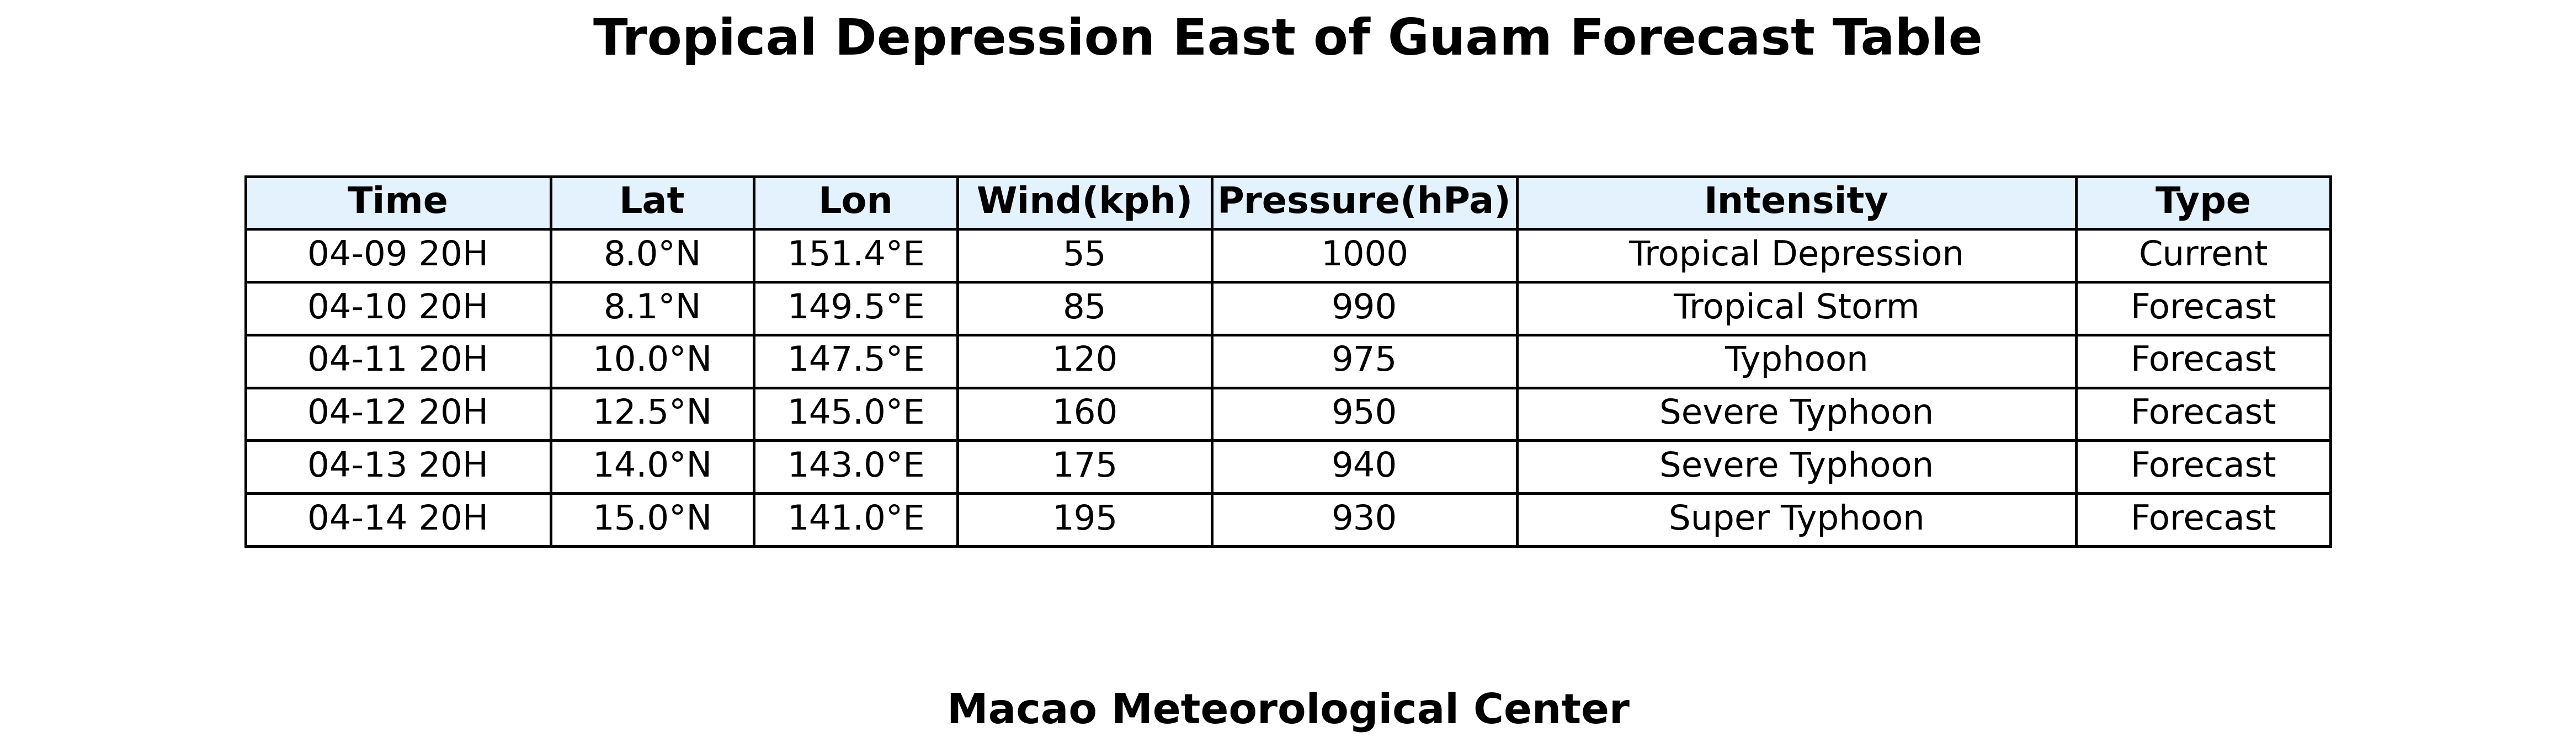

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

forecast_table = []
for item in tcPathData:
    if item["type"] == "current" or (item["type"] == "forecast" and item["hours"] in {24,48,72,96,120}):
        t = item["time"]
        lat = item["lat"]
        lon = item["lng"]
        w = item["speed"]
        p = item["pressure"]
        typ = "Current" if item["type"] == "current" else "Forecast"
        inten, _, _ = get_intensity_info(w)
        forecast_table.append([t, f"{lat:.1f}°N", f"{lon:.1f}°E", w, p, inten, typ])

df = pd.DataFrame(forecast_table, columns=["Time", "Lat", "Lon", "Wind(kph)", "Pressure(hPa)", "Intensity", "Type"])

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center',
    colWidths=[0.12, 0.08, 0.08, 0.10, 0.12, 0.22, 0.10]
)

table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 2.2)  

for (i, j), cell in table.get_celld().items():
    if i == 0:  
        cell.set_facecolor('#E3F2FD') 
        cell.set_text_props(weight='bold', fontsize=16)
    cell.set_edgecolor('black') 
    cell.set_linewidth(1.2)
    cell.PAD = 0.05

plt.title("Tropical Depression East of Guam Forecast Table", fontsize=22, pad=25, fontweight='bold')

plt.figtext(0.5, 0.03,  
            "Macao Meteorological Center", 
            ha='center',  
            fontsize=18,  
            fontweight='bold')  

plt.subplots_adjust(left=0.02, right=0.98, top=0.85, bottom=0.18)

#save_path = r"C:\Users\andyzhang\Documents\GitHub\moweather2021\TC-Track\TC-Intensity-A.png"
#plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.show()